[1/4] Loading label map …
      ✓ 60 classes loaded.
[2/4] Loading models …
      ✓ All models loaded. (device=cuda)
[3/4] Reading image: /home/raghav/Desktop/Minor/Minor/vehicles-nepal-1763346990.jpg
      ✓ Image shape: (500, 622, 3)

[Stage 1] Running plate detector …
          Plates found: 1

────────────────────────────────────────────────────────────
  Stage 1 — Plate YOLO output
────────────────────────────────────────────────────────────


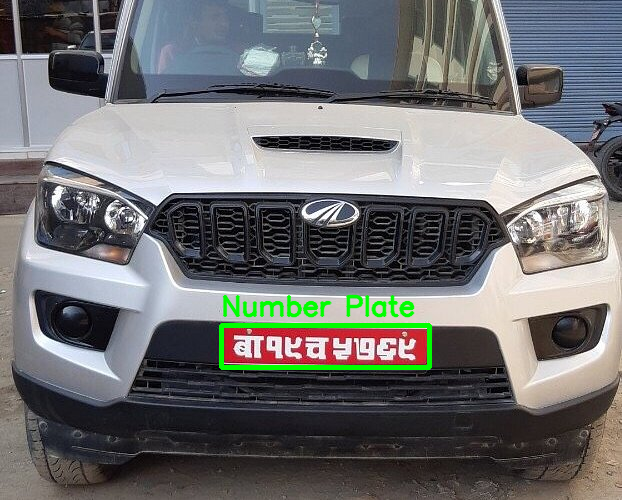


  ── Plate 1 ─────────────────────────────
  [Stage 2] Running character detector …
            Characters found: 8

────────────────────────────────────────────────────────────
  Stage 2 — Char YOLO output | Plate 1
────────────────────────────────────────────────────────────


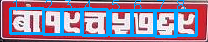

  [Stage 3+4] Preprocessing + OCR …
             Char  1: 'बा'  conf=100.0%
             Char  2: '१'  conf=100.0%
             Char  3: '९'  conf=100.0%
             Char  4: 'च'  conf=100.0%
             Char  5: '५'  conf=68.7%
             Char  6: '७'  conf=100.0%
             Char  7: '६'  conf=100.0%
             Char  8: '९'  conf=100.0%

            ✓ Plate string: बा१९च५७६९

────────────────────────────────────────────────────────────
  Stage 3+4 — B&W crops + OCR predictions | Plate 1
────────────────────────────────────────────────────────────


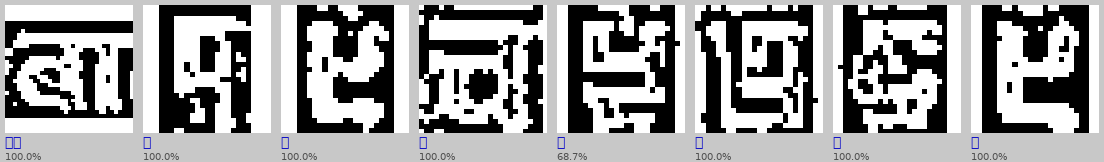


────────────────────────────────────────────────────────────
  Final Result: 'बा१९च५७६९' | Plate 1
────────────────────────────────────────────────────────────


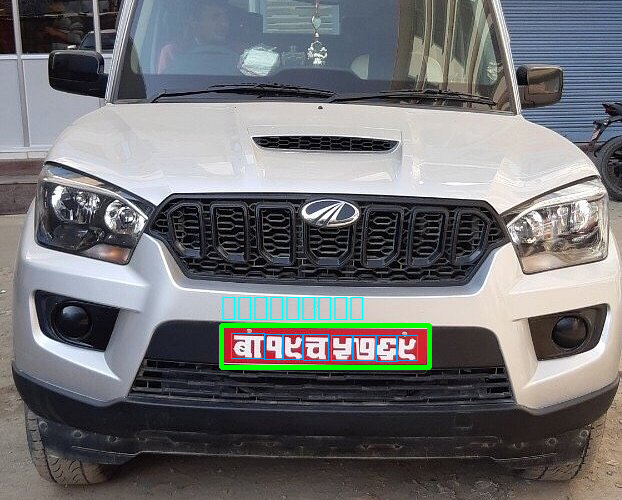


────────────────────────────────────────────────────────────
  Pipeline complete.
────────────────────────────────────────────────────────────


In [ ]:
#imports
import json as _json
import math
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display as ipy_display
from ultralytics import YOLO



IMAGE_PATH        = "vehicles-nepal-1763346990.jpg"
PLATE_MODEL_PATH  = "final_models/plate.pt"
CHAR_MODEL_PATH   = "final_models/plate_char.pt"
OCR_MODEL_PATH    = "final_models/ocr_model_final.pth"
LABEL_MAP_PATH    = "final_models/label_map.json"

PLATE_CONF        = 0.5
CHAR_CONF         = 0.5
DEVICE            = "cuda" if torch.cuda.is_available() else "cpu"

#label
def load_label_map(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        raw = _json.load(f)
    return {int(k): v for k, v in raw.items()}


#ocr model

class OCRModel(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = models.resnet18(weights=None)
        self.features.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2,
                                         padding=3, bias=False)
        self.features.fc = nn.Identity()
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


#transform
_to_tensor = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


#preprocessing

def preprocess_char_crop(char_crop_bgr: np.ndarray,
                          model: nn.Module,
                          device: str,
                          label_map: dict):
    """
    1. BGR → Grayscale
    2. Pad to square with white
    3. CLAHE  (clipLimit=2.0, tileGridSize=8x8)
    4. Gaussian blur  (3x3)
    5. Adaptive threshold  (Gaussian, block=11, C=2)
    6. Resize 128x128 → Normalize(0.5,0.5) → tensor → OCR
    Returns: char (str), conf (float), bw_viz (128x128 uint8)
    """
    gray = cv2.cvtColor(char_crop_bgr, cv2.COLOR_BGR2GRAY)

    h, w = gray.shape
    diff = abs(h - w)
    p1, p2 = diff // 2, diff - diff // 2
    if h < w:
        gray = cv2.copyMakeBorder(gray, p1, p2, 0, 0, cv2.BORDER_CONSTANT, value=255)
    elif w < h:
        gray = cv2.copyMakeBorder(gray, 0, 0, p1, p2, cv2.BORDER_CONSTANT, value=255)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray  = clahe.apply(gray)
    gray  = cv2.GaussianBlur(gray, (3, 3), 0)
    gray  = cv2.adaptiveThreshold(gray, 255,
                                   cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY, 11, 2)

    bw_viz = cv2.resize(gray, (128, 128), interpolation=cv2.INTER_NEAREST)
    pil    = Image.fromarray(gray, mode="L")
    tensor = _to_tensor(pil).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor)
        probs  = F.softmax(logits, dim=-1)
        conf, idx = probs.max(dim=-1)

    char = label_map.get(idx.item(), "?")
    return char, conf.item(), bw_viz


# model loader

def load_yolo(path: str, device: str) -> YOLO:
    mdl = YOLO(path)
    mdl.to(device)
    return mdl


def load_ocr_model(path: str, num_classes: int, device: str) -> nn.Module:
    mdl = OCRModel(num_classes=num_classes)
    state = torch.load(path, map_location=device)
    if isinstance(state, dict) and "model_state_dict" in state:
        state = state["model_state_dict"]
    mdl.load_state_dict(state)
    mdl.to(device)
    mdl.eval()
    return mdl

# Detection helpers

def detect_plates(yolo, image_bgr, conf):
    results = yolo(image_bgr, conf=conf, verbose=False)[0]
    return [tuple(map(int, box.xyxy[0].tolist())) for box in results.boxes]


def detect_chars(yolo, plate_crop_bgr, conf):
    """Group detected chars into rows by y-center, sort each row L→R."""
    results = yolo(plate_crop_bgr, conf=conf, verbose=False)[0]
    boxes   = [tuple(map(int, box.xyxy[0].tolist())) for box in results.boxes]
    if not boxes:
        return []

    heights       = [b[3] - b[1] for b in boxes]
    row_threshold = np.median(heights) * 0.5

    sorted_by_y = sorted(boxes, key=lambda b: (b[1] + b[3]) / 2)
    rows        = []
    current_row = [sorted_by_y[0]]

    for box in sorted_by_y[1:]:
        prev_yc = (current_row[-1][1] + current_row[-1][3]) / 2
        curr_yc = (box[1] + box[3]) / 2
        if abs(curr_yc - prev_yc) <= row_threshold:
            current_row.append(box)
        else:
            rows.append(sorted(current_row, key=lambda b: b[0]))
            current_row = [box]
    rows.append(sorted(current_row, key=lambda b: b[0]))

    return [box for row in rows for box in row]


# drawing

def show_bgr(image_bgr: np.ndarray, title: str):
    print(f"\n{'─'*60}\n  {title}\n{'─'*60}")
    ipy_display(Image.fromarray(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)))


def show_bw_grid(bw_crops, chars, confs, title):
    print(f"\n{'─'*60}\n  {title}\n{'─'*60}")
    n = len(bw_crops)
    if n == 0:
        print("  (no crops to display)")
        return
    cols   = min(n, 10)
    rows   = math.ceil(n / cols)
    cell_w, cell_h = 138, 162
    canvas = np.ones((rows * cell_h, cols * cell_w), dtype=np.uint8) * 200
    for i, crop in enumerate(bw_crops):
        r, c = i // cols, i % cols
        canvas[r*cell_h+5:r*cell_h+133, c*cell_w+5:c*cell_w+133] = crop
    pil  = Image.fromarray(canvas, mode="L").convert("RGB")
    draw = ImageDraw.Draw(pil)
    try:
        font_big = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", size=14)
        font_sm  = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", size=10)
    except Exception:
        font_big = font_sm = ImageFont.load_default()
    for i, (char, conf) in enumerate(zip(chars, confs)):
        r, c = i // cols, i % cols
        tx = c * cell_w + 5
        draw.text((tx, r*cell_h+134), char,       font=font_big, fill=(20, 20, 200))
        draw.text((tx, r*cell_h+150), f"{conf*100:.1f}%", font=font_sm,  fill=(80, 80, 80))
    ipy_display(pil)


def draw_plate_box(image_bgr, plate_box):
    vis = image_bgr.copy()
    px1, py1, px2, py2 = plate_box
    cv2.rectangle(vis, (px1, py1), (px2, py2), (0, 255, 0), 3)
    cv2.putText(vis, "Number Plate", (px1, max(py1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2, cv2.LINE_AA)
    return vis


def draw_char_boxes(plate_crop_bgr, char_boxes):
    vis = plate_crop_bgr.copy()
    for i, (cx1, cy1, cx2, cy2) in enumerate(char_boxes):
        cv2.rectangle(vis, (cx1, cy1), (cx2, cy2), (255, 165, 0), 2)
        cv2.putText(vis, str(i+1), (cx1, max(cy1 - 4, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 165, 0), 1)
    return vis


def draw_final(image_bgr, plate_box, char_boxes, plate_text):
    vis = image_bgr.copy()
    px1, py1, px2, py2 = plate_box
    cv2.rectangle(vis, (px1, py1), (px2, py2), (0, 255, 0), 3)
    for (cx1, cy1, cx2, cy2) in char_boxes:
        cv2.rectangle(vis, (px1+cx1, py1+cy1), (px1+cx2, py1+cy2), (255, 165, 0), 1)
    pil  = Image.fromarray(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    draw = ImageDraw.Draw(pil)
    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
                                  size=max(20, int((px2 - px1) / 8)))
    except Exception:
        font = ImageFont.load_default()
    draw.text((px1, max(py1 - 35, 10)), plate_text, font=font, fill=(0, 255, 255))
    return cv2.cvtColor(np.array(pil), cv2.COLOR_RGB2BGR)




def process_frame(frame, plate_yolo, char_yolo, ocr_model, label_map,
                  plate_conf=PLATE_CONF, char_conf=CHAR_CONF, device=DEVICE):
    """
    Run full ANPR on one BGR frame.
    Returns (annotated_frame, list_of_plate_strings).
    """
    plate_boxes = detect_plates(plate_yolo, frame, plate_conf)
    annotated   = frame.copy()
    plate_texts = []

    for plate_box in plate_boxes:
        px1, py1, px2, py2 = plate_box
        plate_crop = frame[py1:py2, px1:px2]
        if plate_crop.size == 0:
            continue
        char_boxes      = detect_chars(char_yolo, plate_crop, char_conf)
        predicted_chars = []
        for (cx1, cy1, cx2, cy2) in char_boxes:
            char_crop = plate_crop[cy1:cy2, cx1:cx2]
            if char_crop.size == 0:
                continue
            char, _, _ = preprocess_char_crop(char_crop, ocr_model, device, label_map)
            predicted_chars.append(char)
        plate_text = "".join(predicted_chars)
        plate_texts.append(plate_text)
        annotated = draw_final(annotated, plate_box, char_boxes, plate_text)

    return annotated, plate_texts


#impage pipeline

def run_pipeline():
    print("[1/4] Loading label map …")
    label_map   = load_label_map(LABEL_MAP_PATH)
    num_classes = len(label_map)
    print(f"      ✓ {num_classes} classes loaded.")

    print("[2/4] Loading models …")
    plate_yolo = load_yolo(PLATE_MODEL_PATH, DEVICE)
    char_yolo  = load_yolo(CHAR_MODEL_PATH,  DEVICE)
    ocr_model  = load_ocr_model(OCR_MODEL_PATH, num_classes, DEVICE)
    print(f"      ✓ All models loaded. (device={DEVICE})")

    print(f"[3/4] Reading image: {IMAGE_PATH}")
    image = cv2.imread(IMAGE_PATH)
    if image is None:
        raise FileNotFoundError(f"Could not read image at '{IMAGE_PATH}'")
    print(f"      ✓ Image shape: {image.shape}")

    print("\n[Stage 1] Running plate detector …")
    plate_boxes = detect_plates(plate_yolo, image, PLATE_CONF)
    print(f"          Plates found: {len(plate_boxes)}")

    if not plate_boxes:
        print("          No plates detected. Try lowering PLATE_CONF.")
        return

    vis_stage1 = image.copy()
    for pb in plate_boxes:
        vis_stage1 = draw_plate_box(vis_stage1, pb)
    show_bgr(vis_stage1, "Stage 1 — Plate YOLO output")

    for plate_idx, plate_box in enumerate(plate_boxes):
        px1, py1, px2, py2 = plate_box
        plate_crop = image[py1:py2, px1:px2]
        if plate_crop.size == 0:
            print(f"  [Plate {plate_idx+1}] Empty crop — skipping.")
            continue

        print(f"\n  ── Plate {plate_idx+1} ─────────────────────────────")
        print("  [Stage 2] Running character detector …")
        char_boxes = detect_chars(char_yolo, plate_crop, CHAR_CONF)
        print(f"            Characters found: {len(char_boxes)}")

        if not char_boxes:
            print("            No characters found. Try lowering CHAR_CONF.")
            continue

        show_bgr(draw_char_boxes(plate_crop, char_boxes),
                 f"Stage 2 — Char YOLO output | Plate {plate_idx+1}")

        print("  [Stage 3+4] Preprocessing + OCR …")
        predicted_chars, confs, bw_crops = [], [], []

        for box_idx, (cx1, cy1, cx2, cy2) in enumerate(char_boxes):
            char_crop = plate_crop[cy1:cy2, cx1:cx2]
            if char_crop.size == 0:
                print(f"             ⚠ Empty crop at box {box_idx+1} — skipped.")
                continue
            char, conf, bw_viz = preprocess_char_crop(
                char_crop, ocr_model, DEVICE, label_map)
            predicted_chars.append(char)
            confs.append(conf)
            bw_crops.append(bw_viz)
            print(f"             Char {box_idx+1:>2}: '{char}'  conf={conf*100:.1f}%")

        plate_text = "".join(predicted_chars)
        print(f"\n            ✓ Plate string: {plate_text}")

        show_bw_grid(bw_crops, predicted_chars, confs,
                     f"Stage 3+4 — B&W crops + OCR predictions | Plate {plate_idx+1}")
        show_bgr(draw_final(image, plate_box, char_boxes, plate_text),
                 f"Final Result: '{plate_text}' | Plate {plate_idx+1}")

    print(f"\n{'─'*60}\n  Pipeline complete.\n{'─'*60}")


run_pipeline()


In [ ]:
# IMAGE_PATH is now defined directly in the pipeline cell above.
# You can still override it here:
IMAGE_PATH = "/home/raghav/Desktop/Minor/Minor/vehicles-nepal-1763346990.jpg"